# 03 - Finetune YOLOP (Colab GPU)

Fine-tunes `hustvl/YOLOP` on a mixed dataset (CARLA synthetic + pseudo-labeled real) with:
- YOLOP pretrained weights (full architecture match, no partial transfer)
- deterministic train/val/test split persisted on Google Drive
- checkpointing + automatic resume after kernel restarts
- early stopping (patience=10)
- cosine LR decay + AdamW
- domain adaptation via a lightweight discriminator on P4 features
- training curves saved and plotted consistently across sessions

## Section 1 — Setup

Installs dependencies, downloads YOLOP source and pretrained weights, mounts Google Drive, and defines all paths and hyperparameters.

In [ ]:
%pip install -q opencv-python pandas numpy matplotlib tqdm onnx onnxruntime onnxruntime-gpu yacs pyyaml --quiet
!pip install -q prefetch_generator --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 4.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import sys
import json
import time
import math
import zipfile
import urllib.request
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

# This clones YOLOP into torch hub cache if not already there
torch.hub.load('hustvl/yolop', 'yolop', pretrained=False)

# Add the cached repo to sys.path so lib/ imports work
REPO_ROOT = list(torch.hub.get_dir() and Path(torch.hub.get_dir()).glob('hustvl_yolop*'))[0]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# ── Project paths on Google Drive ───────────────────────────────────────────
PROJECT_ROOT = Path('/content/drive/MyDrive/sdcar-perception')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CARLA_MANIFEST  = PROJECT_ROOT / 'data' / 'carla'  / 'manifest.csv'
PSEUDO_MANIFEST = PROJECT_ROOT / 'data' / 'pseudo' / 'manifest.csv'
MIXED_MANIFEST  = PROJECT_ROOT / 'data' / 'yolopv2_finetune' / 'manifest.csv'

RUN_DIR  = PROJECT_ROOT / 'runs' / 'yolop_finetune'
CKPT_DIR = RUN_DIR / 'checkpoints'
EXPORT_DIR = RUN_DIR / 'exports'
for d in [RUN_DIR, CKPT_DIR, EXPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ──────────────────────────────────────────────────────────
IMAGE_SIZE        = 640
BATCH_SIZE        = 4      # conservative for 15 GB VRAM; increase to 6-8 if stable
NUM_EPOCHS        = 100
PATIENCE          = 10
SEED              = 1337
DOMAIN_LOSS_WEIGHT = 0.1

os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device   :', device)
print('REPO_ROOT:', REPO_ROOT)
print('RUN_DIR  :', RUN_DIR)

# Quick sanity check — should show lib/, tools/, weights/ etc.
!ls {REPO_ROOT}

/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/hustvl/yolop/zipball/main" to /root/.cache/torch/hub/main.zip
Device   : cpu
REPO_ROOT: /root/.cache/torch/hub/hustvl_yolop_main
RUN_DIR  : /content/drive/MyDrive/sdcar-perception/runs/yolop_finetune
 export_onnx.py   lib	     __pycache__      requirements.txt	 toolkits
 hubconf.py	  LICENSE   'README _CH.md'   test.jpg		 tools
 inference	  pictures   README.md	      test_onnx.py	 weights


## Section 2 — Dataset

Reads manifest CSVs and loads per-sample:
- image resized to 640×640
- YOLO detection labels (cls cx cy w h, normalized)
- drivable-area and lane binary masks → 2-channel tensors
- domain label (0 = CARLA synthetic, 1 = real)

In [ ]:
import random
from torch.utils.data import Subset

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)


def _read_yolo_file(path: Path):
    """Parse a YOLO label file into a float32 array of shape (N, 5)."""
    if not path.exists():
        return np.zeros((0, 5), dtype=np.float32)
    rows = []
    for line in path.read_text(encoding='utf-8').splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        rows.append([float(p) for p in parts])
    return np.asarray(rows, dtype=np.float32) if rows else np.zeros((0, 5), dtype=np.float32)


def _binmask_to_2ch(mask: np.ndarray) -> torch.Tensor:
    """Binary (H,W) mask → 2-channel one-hot (2,H,W) expected by YOLOP's seg loss."""
    m  = (mask > 0).astype(np.float32)
    return torch.from_numpy(np.stack([1.0 - m, m], axis=0))


class MixedPerceptionDataset(Dataset):
    def __init__(self, manifest_paths, image_size=640):
        self.df = pd.concat(
            [pd.read_csv(mp) for mp in manifest_paths], ignore_index=True
        )
        self.image_size = int(image_size)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sz  = self.image_size

        # Image
        img = cv2.imread(str(row['image_path']))
        if img is None:
            raise FileNotFoundError(f"Cannot read image: {row['image_path']}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (sz, sz), interpolation=cv2.INTER_LINEAR)
        img_t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0

        # Segmentation masks
        def _load_mask(path):
            m = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
            if m is None:
                m = np.zeros((sz, sz), dtype=np.uint8)
            return cv2.resize(m, (sz, sz), interpolation=cv2.INTER_NEAREST)

        lane_t     = _binmask_to_2ch(_load_mask(row['lane_mask_path']))
        drivable_t = _binmask_to_2ch(_load_mask(row['drivable_mask_path']))

        # Detection labels
        labels = _read_yolo_file(Path(row['label_path']))
        labels_t = torch.from_numpy(labels) if labels.size else torch.zeros((0, 5), dtype=torch.float32)

        # Domain label
        if 'is_real' in row:
            domain = float(row['is_real'])
        else:
            d = row.get('domain', 0)
            domain = 1.0 if (isinstance(d, str) and d.lower() == 'real') else float(d)
        domain_t = torch.tensor([domain], dtype=torch.float32)

        return {
            'image':        img_t,
            'labels':       labels_t,
            'lane_mask':    lane_t,
            'drivable_mask': drivable_t,
            'domain_label': domain_t,
        }


def collate_fn(batch):
    return {
        'image':         torch.stack([b['image']         for b in batch]),
        'labels':        [b['labels'] for b in batch],
        'lane_mask':     torch.stack([b['lane_mask']     for b in batch]),
        'drivable_mask': torch.stack([b['drivable_mask'] for b in batch]),
        'domain_label':  torch.stack([b['domain_label']  for b in batch]),
    }


manifests = (
    [MIXED_MANIFEST] if MIXED_MANIFEST.exists()
    else [p for p in [CARLA_MANIFEST, PSEUDO_MANIFEST] if p.exists()]
)
if not manifests:
    raise FileNotFoundError(
        'No manifests found. Run notebooks 01 and 02 first, '
        'then upload CARLA data to Google Drive.'
    )

full_ds = MixedPerceptionDataset(manifests, image_size=IMAGE_SIZE)
print('Total samples :', len(full_ds))
print('Using manifests:', manifests)

Total samples : 12928
Using manifests: [PosixPath('/content/drive/MyDrive/sdcar-perception/data/yolopv2_finetune/manifest.csv')]


## Section 3 — Train / Val / Test split (persisted)

80 / 10 / 10 split stratified by domain so both CARLA and real samples appear
in each subset proportionally. Saved to Drive so it is identical across sessions.

In [ ]:
SPLIT_PATH = RUN_DIR / 'split_indices.pt'

df_all = full_ds.df.reset_index(drop=True)

def get_is_real(row):
    if 'is_real' in row:
        try:
            return int(row['is_real'])
        except Exception:
            pass
    d = row.get('domain', 0)
    return 1 if (isinstance(d, str) and d.lower() == 'real') else int(d)

if SPLIT_PATH.exists():
    split = torch.load(SPLIT_PATH, map_location='cpu', weights_only=True)
    train_idx, val_idx, test_idx = split['train'], split['val'], split['test']
    print('Loaded existing split from Drive.')
else:
    rng = np.random.default_rng(SEED)
    train_idx, val_idx, test_idx = [], [], []

    for is_real in [0, 1]:
        idxs = [int(i) for i, row in df_all.iterrows() if get_is_real(row) == is_real]
        rng.shuffle(idxs)
        n = len(idxs)
        n_train = int(0.8 * n)
        n_val   = int(0.1 * n)
        train_idx += idxs[:n_train]
        val_idx   += idxs[n_train:n_train + n_val]
        test_idx  += idxs[n_train + n_val:]

    rng.shuffle(train_idx)
    rng.shuffle(val_idx)
    rng.shuffle(test_idx)

    torch.save({'train': train_idx, 'val': val_idx, 'test': test_idx, 'seed': SEED}, SPLIT_PATH)
    print('Created and saved new split.')

train_ds = Subset(full_ds, train_idx)
val_ds   = Subset(full_ds, val_idx)
test_ds  = Subset(full_ds, test_idx)

loader_kw = dict(batch_size=BATCH_SIZE, num_workers=2, pin_memory=True, collate_fn=collate_fn)
train_loader = DataLoader(train_ds, shuffle=True,  **loader_kw)
val_loader   = DataLoader(val_ds,   shuffle=False, **loader_kw)
test_loader  = DataLoader(test_ds,  shuffle=False, **loader_kw)

print('Split sizes:', {'train': len(train_ds), 'val': len(val_ds), 'test': len(test_ds)})

Loaded existing split from Drive.
Split sizes: {'train': 10342, 'val': 1292, 'test': 1294}


## Section 4 — Model assembly

- Builds YOLOP using its own config and `get_net`
- Loads YOLOP's own pretrained weights (full architecture match)
- Attaches a lightweight domain discriminator on the P4 feature map
- Sets up optimizer, scheduler, AMP scaler

The FeatureTap hooks only Conv2d layers to avoid retaining activations from
every module in memory (which caused OOM with the previous approach).

In [ ]:
from lib.config import cfg as yolop_cfg
from lib.models import get_net
from lib.core.loss import get_loss
from src.academic.discriminator import DomainDiscriminator

# ── Build model and load weights ────────────────────────────────────────────
model = torch.hub.load(
    'hustvl/yolop',
    'yolop',
    pretrained=True,
    device='cpu'
)
model.gr = 1.0
model = model.to(device)
print('Loaded YOLOP via torch.hub')

# ── Feature tap for domain adaptation ───────────────────────────────────────
# Hooks only Conv2d layers (not every module) to avoid retaining all
# intermediate activations in memory simultaneously.
class FeatureTap:
    """Captures the first Conv2d output matching (channels, spatial) criteria."""
    def __init__(self, m, channels=256, stride=16):
        self.channels = channels
        self.spatial  = int(IMAGE_SIZE // stride)  # 640//16 = 40
        self.last     = None
        self.handles  = []
        for module in m.modules():
            if isinstance(module, nn.Conv2d):
                self.handles.append(module.register_forward_hook(self._hook))

    def _hook(self, _, __, output):
        if self.last is not None:
            return
        if output.dim() == 4:
            b, c, h, w = output.shape
            if c == self.channels and h == self.spatial and w == self.spatial:
                self.last = output

    def clear(self):
        self.last = None

feature_tap = FeatureTap(model, channels=256, stride=16)
feature_tap_warned = False

# Verify the tap finds the P4 feature map
with torch.no_grad():
    feature_tap.clear()
    dummy = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)
    _ = model(dummy)
    if feature_tap.last is None:
        print('Warning: could not locate 256x40x40 P4 feature map — domain loss will be skipped.')
    else:
        print(f'P4 feature tap confirmed: {feature_tap.last.shape}')

# ── Domain discriminator ─────────────────────────────────────────────────────
domain_disc    = DomainDiscriminator().to(device)
# BCEWithLogitsLoss is autocast-safe and numerically more stable than BCELoss.
# Remove any sigmoid from the final layer of DomainDiscriminator if present.
domain_loss_fn = nn.BCEWithLogitsLoss()

# ── YOLOP multi-task loss ────────────────────────────────────────────────────
criterion = get_loss(yolop_cfg, device)

# ── Optimizer, scheduler, AMP scaler ────────────────────────────────────────
optimizer = torch.optim.AdamW(
    list(model.parameters()) + list(domain_disc.parameters()),
    lr=1e-4,
    weight_decay=1e-4,
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6
)
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

print('Model ready on', device)

Using cache found in /root/.cache/torch/hub/hustvl_yolop_main


Loaded YOLOP via torch.hub
P4 feature tap confirmed: torch.Size([1, 256, 40, 40])
Model ready on cpu


## Section 5 — Training loop (resumable)

- Saves `last.pt` every epoch and `best.pt` on validation improvement
- Saves a snapshot every 10 epochs
- Appends metrics to `history.csv` on Drive
- Early stopping with patience=10 on validation total loss
- Gradient clipping (max_norm=10)

In [ ]:
# Patch YOLOP's postprocess.py for PyTorch 2.x compatibility
postprocess_path = REPO_ROOT / 'lib' / 'core' / 'postprocess.py'
src = postprocess_path.read_text()

# The fix: cast to long before clamp_ instead of relying on implicit cast
old = 'indices.append((b, a, gj.clamp_(0, gain[3] - 1), gi.clamp_(0, gain[2] - 1)))'
new = 'indices.append((b, a, gj.long().clamp_(0, int(gain[3]) - 1), gi.long().clamp_(0, int(gain[2]) - 1)))'

if old in src:
    postprocess_path.write_text(src.replace(old, new))
    print('Patched postprocess.py')
else:
    print('Pattern not found — may already be patched or line differs')
    print('Check manually:', postprocess_path)

Patched postprocess.py


In [ ]:
import importlib
import lib.core.postprocess
importlib.reload(lib.core.postprocess)
import lib.core.loss
importlib.reload(lib.core.loss)
from lib.core.loss import get_loss
criterion = get_loss(yolop_cfg, device)
print('criterion reloaded')

criterion reloaded


In [ ]:
HISTORY_CSV = RUN_DIR / 'history.csv'
LAST_CKPT   = CKPT_DIR / 'last.pt'
BEST_CKPT   = CKPT_DIR / 'best.pt'


def build_det_targets(labels_list, device):
    """Stack per-image YOLO labels into YOLOP's (N,6) format: [img_idx, cls, cx, cy, w, h]."""
    out = []
    for i, lab in enumerate(labels_list):
        if lab is None or lab.numel() == 0:
            continue
        lab = lab.to(device)
        img_idx = torch.full((lab.shape[0], 1), i, device=device, dtype=lab.dtype)
        out.append(torch.cat([img_idx, lab[:, 0:1], lab[:, 1:]], dim=1))
    return torch.cat(out, dim=0) if out else torch.zeros((0, 6), device=device)


def forward_unpack(model, images):
    """Run model and return (det_out, da_seg_out, ll_seg_out)."""
    out = model(images)
    if isinstance(out, (list, tuple)) and len(out) >= 3:
        return out[0], out[1], out[2]
    raise RuntimeError(f'Unexpected model output: {type(out)}')


def eval_one_epoch(model, loader):
    model.eval()
    totals = {k: 0.0 for k in ['total','lbox','lobj','lcls','lseg_da','lseg_ll','liou_ll']}
    n_batches = 0

    with torch.no_grad():
        for batch in loader:
            images  = batch['image'].to(device)
            da_gt   = batch['drivable_mask'].to(device)
            ll_gt   = batch['lane_mask'].to(device)
            det_t   = build_det_targets(batch['labels'], device)
            bsz     = images.shape[0]
            shapes  = [((IMAGE_SIZE, IMAGE_SIZE), ((1.0, 1.0), (0, 0))) for _ in range(bsz)]

            # YOLOP's loss expects train-mode output format (raw grid tensors, not concatenated).
            # Switch to train mode just for the forward pass, then back to eval.
            model.train()
            det_out, da_out, ll_out = forward_unpack(model, images)
            model.eval()

            loss, parts = criterion([det_out, da_out, ll_out], [det_t, da_gt, ll_gt], shapes, model)
            lbox, lobj, lcls, lseg_da, lseg_ll, liou_ll, ltotal = parts

            totals['total']   += float(ltotal)
            totals['lbox']    += float(lbox)
            totals['lobj']    += float(lobj)
            totals['lcls']    += float(lcls)
            totals['lseg_da'] += float(lseg_da)
            totals['lseg_ll'] += float(lseg_ll)
            totals['liou_ll'] += float(liou_ll)
            n_batches += 1

    model.eval()  # ensure eval mode is restored after the loop
    if n_batches == 0:
        return {k: math.inf for k in totals}
    return {k: v / n_batches for k, v in totals.items()}



In [ ]:
# ── Resume state ─────────────────────────────────────────────────────────────
history      = []
start_epoch  = 1
best_val     = math.inf
patience_left = PATIENCE

if HISTORY_CSV.exists():
    try:
        history = pd.read_csv(HISTORY_CSV).to_dict('records')
    except Exception:
        history = []

if LAST_CKPT.exists():
    ck = torch.load(LAST_CKPT, map_location=device, weights_only=True)
    model.load_state_dict(ck['model'], strict=False)
    if ck.get('domain_disc') is not None:
        domain_disc.load_state_dict(ck['domain_disc'], strict=False)
    optimizer.load_state_dict(ck['optimizer'])
    scheduler.load_state_dict(ck['scheduler'])
    if ck.get('scaler') is not None:
        scaler.load_state_dict(ck['scaler'])
    start_epoch   = int(ck.get('epoch', 0)) + 1
    best_val      = float(ck.get('best_val', best_val))
    patience_left = int(ck.get('patience_left', PATIENCE))
    print('Resumed from epoch', start_epoch - 1)

print('Resume state:', {'start_epoch': start_epoch, 'best_val': best_val, 'patience_left': patience_left})


# ── Training loop ─────────────────────────────────────────────────────────────
for epoch in range(start_epoch, NUM_EPOCHS + 1):
    model.train()
    domain_disc.train()

    running   = {k: 0.0 for k in ['total','lbox','lobj','lcls','lseg_da','lseg_ll','liou_ll','ldomain']}
    n_batches = 0

    for step, batch in enumerate(tqdm(train_loader, desc=f'Train epoch {epoch}'), start=1):
        images        = batch['image'].to(device)
        da_gt         = batch['drivable_mask'].to(device)
        ll_gt         = batch['lane_mask'].to(device)
        det_t         = build_det_targets(batch['labels'], device)
        domain_target = batch['domain_label'].to(device)
        bsz           = images.shape[0]
        shapes        = [((IMAGE_SIZE, IMAGE_SIZE), ((1.0, 1.0), (0, 0))) for _ in range(bsz)]

        optimizer.zero_grad(set_to_none=True)
        torch.cuda.empty_cache()

        feature_tap.clear()
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            det_out, da_out, ll_out = forward_unpack(model, images)
            loss, parts = criterion([det_out, da_out, ll_out], [det_t, da_gt, ll_gt], shapes, model)
            lbox, lobj, lcls, lseg_da, lseg_ll, liou_ll, ltotal = parts

            domain_loss = torch.tensor(0.0, device=device)
            if feature_tap.last is not None:
                domain_pred = domain_disc(feature_tap.last)
                domain_loss = domain_loss_fn(domain_pred, domain_target)
            elif not feature_tap_warned:
                print('Warning: P4 feature map not found — domain loss disabled.')
                feature_tap_warned = True

            total_loss = loss + DOMAIN_LOSS_WEIGHT * domain_loss

        scaler.scale(total_loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        scaler.step(optimizer)
        scaler.update()

        running['total']   += float(ltotal)
        running['lbox']    += float(lbox)
        running['lobj']    += float(lobj)
        running['lcls']    += float(lcls)
        running['lseg_da'] += float(lseg_da)
        running['lseg_ll'] += float(lseg_ll)
        running['liou_ll'] += float(liou_ll)
        running['ldomain'] += float(domain_loss)
        n_batches += 1

        if step % 25 == 0:
            r = {k: v / n_batches for k, v in running.items()}
            print(
                f"epoch={epoch} step={step} "
                f"total={r['total']:.4f} box={r['lbox']:.4f} obj={r['lobj']:.4f} "
                f"cls={r['lcls']:.4f} da={r['lseg_da']:.4f} ll={r['lseg_ll']:.4f} "
                f"liou_ll={r['liou_ll']:.4f} domain={r['ldomain']:.4f} "
                f"lr={optimizer.param_groups[0]['lr']:.2e}"
            )

    train_metrics = {k: v / max(n_batches, 1) for k, v in running.items()}
    val_metrics   = eval_one_epoch(model, val_loader)
    scheduler.step()

    row = {
        'epoch': epoch,
        'lr': optimizer.param_groups[0]['lr'],
        **{f'train_{k}': v for k, v in train_metrics.items()},
        **{f'val_{k}':   v for k, v in val_metrics.items()},
        'best_val_total': best_val,
        'patience_left':  patience_left,
        'time': time.time(),
    }
    history.append(row)
    pd.DataFrame(history).to_csv(HISTORY_CSV, index=False)

    # Save last checkpoint every epoch
    ckpt_payload = {
        'epoch':        epoch,
        'model':        model.state_dict(),
        'domain_disc':  domain_disc.state_dict(),
        'optimizer':    optimizer.state_dict(),
        'scheduler':    scheduler.state_dict(),
        'scaler':       scaler.state_dict(),
        'best_val':     best_val,
        'patience_left': patience_left,
        'image_size':   IMAGE_SIZE,
    }
    torch.save(ckpt_payload, LAST_CKPT)

    # Save best checkpoint on improvement
    if val_metrics['total'] < best_val:
        best_val      = val_metrics['total']
        patience_left = PATIENCE
        torch.save(ckpt_payload | {'best_val': best_val}, BEST_CKPT)
        print(f'  ✓ New best: val_total={best_val:.4f} @ epoch={epoch}')
    else:
        patience_left -= 1
        print(f'  No improvement. patience_left={patience_left}')

    # Periodic snapshot
    if epoch % 10 == 0:
        torch.save({'epoch': epoch, 'model': model.state_dict(), 'best_val': best_val},
                   CKPT_DIR / f'epoch_{epoch}.pt')

    if patience_left <= 0:
        print(f'Early stopping at epoch {epoch}.')
        break

print('Training complete. Best val total:', best_val)
print('History saved to', HISTORY_CSV)

Resumed from epoch 5
Resume state: {'start_epoch': 6, 'best_val': 0.4841918675892124, 'patience_left': 7}


Train epoch 6:   0%|          | 0/2586 [00:00<?, ?it/s]/tmp/ipykernel_15036/4248464412.py:141: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  running['ldomain'] += float(domain_loss)
Train epoch 6:   1%|          | 25/2586 [03:08<1:54:12,  2.68s/it]

epoch=6 step=25 total=0.4812 box=0.0263 obj=0.0071 cls=0.0000 da=0.1247 ll=0.1231 liou_ll=0.2000 domain=0.4671 lr=9.94e-05


Train epoch 6:   2%|▏         | 50/2586 [04:04<1:22:16,  1.95s/it]

epoch=6 step=50 total=0.4795 box=0.0246 obj=0.0070 cls=0.0000 da=0.1247 ll=0.1231 liou_ll=0.2000 domain=0.4643 lr=9.94e-05


...

Train epoch 7:  27%|██▋       | 700/2586 [06:01<14:32,  2.16it/s]

epoch=7 step=700 total=0.4807 box=0.0257 obj=0.0071 cls=0.0000 da=0.1247 ll=0.1231 liou_ll=0.2000 domain=0.5340 lr=9.91e-05


Train epoch 7:  28%|██▊       | 725/2586 [06:14<14:06,  2.20it/s]

epoch=7 step=725 total=0.4807 box=0.0257 obj=0.0071 cls=0.0000 da=0.1247 ll=0.1231 liou_ll=0.2000 domain=0.5328 lr=9.91e-05


Train epoch 7:  29%|██▉       | 749/2586 [06:26<14:01,  2.18it/s]

## Section 6 — Evaluation, export, and training curves

- Evaluates best checkpoint on the held-out test split
- Exports clean `.pt` weights, FP32 ONNX, and INT8 ONNX
- Plots training curves from the persisted `history.csv`

Evaluating best checkpoint on test split...


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Test metrics: {'total': '0.4834', 'lbox': '0.0335', 'lobj': '0.0084', 'lcls': '0.0000', 'lseg_da': '0.1253', 'lseg_ll': '0.1232', 'liou_ll': '0.1931'}
Saved PT weights: /content/drive/MyDrive/sdcar-perception/runs/yolop_finetune/exports/yolop_finetuned.pt


/tmp/ipykernel_27571/505669439.py:34: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0512 12:18:31.743000 27571 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 16 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0512 12:18:33.272000 27571 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int'

[torch.onnx] Obtain model graph for `ExportWrapper([...]` with `torch.export.export(..., strict=False)`...


...

W0512 12:18:49.954000 27571 torch/onnx/_internal/exporter/_core.py:1248] Tensor 'm.model.24.stride' is not one of the initializers


[torch.onnx] Translate the graph into ONNX... ✅


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/BaseConverter.h:64: adapter_lookup: Assertion `false`

Saved ONNX FP32: /content/drive/MyDrive/sdcar-perception/runs/yolop_finetune/exports/yolop_finetuned.onnx


Saved ONNX INT8: /content/drive/MyDrive/sdcar-perception/runs/yolop_finetune/exports/yolop_finetuned_int8.onnx


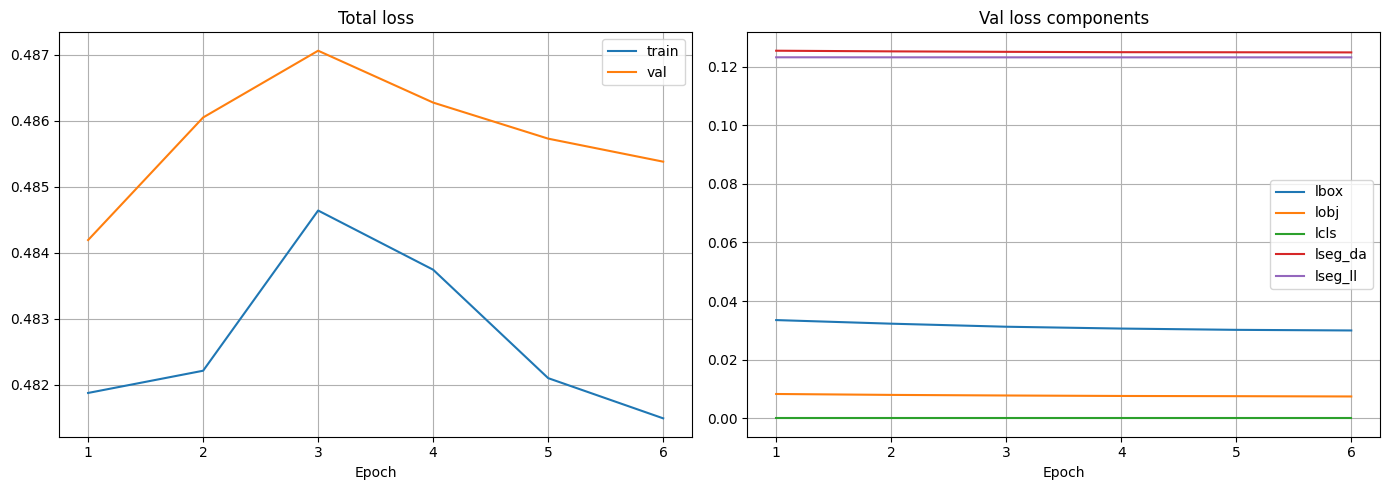

Curves saved to /content/drive/MyDrive/sdcar-perception/runs/yolop_finetune/training_curves.png


In [ ]:
import matplotlib.pyplot as plt
import onnx
import onnxruntime as ort
from onnxruntime.quantization import quantize_dynamic, QuantType

# ── Load best checkpoint ──────────────────────────────────────────────────────
best = torch.load(BEST_CKPT, map_location=device, weights_only=True)
model.load_state_dict(best['model'], strict=False)
model.eval()

print('Evaluating best checkpoint on test split...')
test_metrics = eval_one_epoch(model, test_loader)
print('Test metrics:', {k: f"{v:.4f}" for k, v in test_metrics.items()})

# ── Export weights ────────────────────────────────────────────────────────────
pt_weights = EXPORT_DIR / 'yolop_finetuned.pt'
torch.save(model.state_dict(), pt_weights)
print('Saved PT weights:', pt_weights)

# ── ONNX export ───────────────────────────────────────────────────────────────
class ExportWrapper(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, images):
        return forward_unpack(self.m, images)

onnx_fp32 = EXPORT_DIR / 'yolop_finetuned.onnx'
onnx_int8 = EXPORT_DIR / 'yolop_finetuned_int8.onnx'
dummy = torch.randn(1, 3, IMAGE_SIZE, IMAGE_SIZE, device=device)

export_model = ExportWrapper(model).to(device).eval()
with torch.no_grad():
    torch.onnx.export(
        export_model, dummy, str(onnx_fp32),
        opset_version=16,
        input_names=['images'],
        output_names=['det', 'drivable', 'lane'],
        do_constant_folding=True,
        dynamic_axes={'images': {0: 'batch'}},
    )
print('Saved ONNX FP32:', onnx_fp32)

quantize_dynamic(
    model_input=str(onnx_fp32),
    model_output=str(onnx_int8),
    weight_type=QuantType.QInt8,
)
print('Saved ONNX INT8:', onnx_int8)

# ── Training curves ───────────────────────────────────────────────────────────
hist = pd.read_csv(HISTORY_CSV)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hist['epoch'], hist['train_total'], label='train')
axes[0].plot(hist['epoch'], hist['val_total'],   label='val')
axes[0].set_title('Total loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()
axes[0].grid(True)

for key in ['lbox', 'lobj', 'lcls', 'lseg_da', 'lseg_ll']:
    axes[1].plot(hist['epoch'], hist[f'val_{key}'], label=key)
axes[1].set_title('Val loss components')
axes[1].set_xlabel('Epoch')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(RUN_DIR / 'training_curves.png', dpi=150)
plt.show()
print('Curves saved to', RUN_DIR / 'training_curves.png')